In [60]:
import pandas as pd
import numpy as np
from scipy.stats import shapiro , normaltest , f_oneway , levene , mannwhitneyu
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
player = pd.read_csv("nba_players.csv")
player_season = pd.read_csv("nba_player_season_stats.csv")
teams = pd.read_csv("nba_teams.csv")
mvp = pd.read_csv("nba_mvp_votes.csv")

In [3]:
player.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1172 entries, 0 to 1171
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   player_id         1172 non-null   int64  
 1   name              1172 non-null   object 
 2   birth_date        1172 non-null   object 
 3   height_cm         1172 non-null   int64  
 4   weight_kg         1172 non-null   int64  
 5   position          1172 non-null   object 
 6   draft_year        749 non-null    float64
 7   nba_debut         1172 non-null   int64  
 8   experience_years  1172 non-null   int64  
 9   is_active         1172 non-null   int64  
 10  birth_place       1172 non-null   object 
 11  shoots            1172 non-null   object 
dtypes: float64(1), int64(6), object(5)
memory usage: 110.0+ KB


In [4]:
player.describe()

,player_id,height_cm,weight_kg,draft_year,nba_debut,experience_years,is_active
count,1172.000000,1172.000000,1172.000000,749.000000,1172.000000,1172.000000,1172.000000
mean,1586.500000,198.715017,96.501706,2017.813084,2019.078498,5.252560,0.621160
std,338.471565,8.413868,10.784869,5.370477,4.967424,4.373006,0.485305
min,1001.000000,170.000000,72.000000,1998.000000,1999.000000,1.000000,0.000000
25%,1293.750000,193.000000,88.000000,2014.000000,2017.000000,2.000000,0.000000
50%,1586.500000,198.000000,96.000000,2019.000000,2020.000000,4.000000,1.000000
75%,1879.250000,203.750000,104.000000,2022.000000,2023.000000,8.000000,1.000000
max,2172.000000,229.000000,141.000000,2025.000000,2026.000000,23.000000,1.000000


In [5]:
teams.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   team_id                   30 non-null     int64 
 1   team_name                 30 non-null     object
 2   from_year                 30 non-null     int64 
 3   to_year                   30 non-null     int64 
 4   total_games               30 non-null     int64 
 5   total_wins                30 non-null     int64 
 6   total_losses              30 non-null     int64 
 7   playoffs                  30 non-null     int64 
 8   conference_championships  30 non-null     int64 
 9   division_championships    30 non-null     int64 
 10  championships             30 non-null     int64 
 11  league                    30 non-null     object
dtypes: int64(10), object(2)
memory usage: 2.9+ KB


In [6]:
teams.describe()

,team_id,from_year,to_year,total_games,total_wins,total_losses,playoffs,conference_championships,division_championships,championships
count,30.000000,30.000000,30.0,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.00000
mean,15.500000,1968.500000,2025.0,4594.666667,2305.333333,2289.266667,33.466667,3.733333,10.633333,2.80000
std,8.803408,16.519059,0.0,1297.404208,749.257257,623.306364,14.672830,3.973475,8.531820,4.38178
min,1.000000,1946.000000,2025.0,1932.000000,878.000000,1054.000000,9.000000,0.000000,0.000000,0.00000
25%,8.250000,1952.000000,2025.0,3829.250000,1880.250000,1878.750000,25.250000,1.000000,6.000000,0.25000
50%,15.500000,1967.000000,2025.0,4770.000000,2439.500000,2301.500000,34.500000,3.000000,8.500000,1.00000
75%,22.750000,1978.500000,2025.0,5889.250000,2802.250000,2673.750000,40.250000,5.000000,12.750000,3.00000
max,30.000000,2002.000000,2025.0,6278.000000,3751.000000,3359.000000,66.000000,19.000000,36.000000,18.00000


In [7]:
mvp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 81 non-null     int64  
 1   player_id          81 non-null     int64  
 2   season_id          81 non-null     int64  
 3   team_id            79 non-null     float64
 4   rank               81 non-null     int64  
 5   first_place_votes  81 non-null     int64  
 6   points_won         81 non-null     int64  
 7   points_max         81 non-null     int64  
 8   share              81 non-null     float64
 9   win_shares         81 non-null     float64
 10  win_shares_per_48  81 non-null     float64
dtypes: float64(4), int64(7)
memory usage: 7.1 KB


In [8]:
mvp.describe()

,id,player_id,season_id,team_id,rank,first_place_votes,points_won,points_max,share,win_shares,win_shares_per_48
count,81.000000,81.000000,81.000000,79.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000
mean,41.000000,1478.234568,3.740741,14.620253,6.345679,8.654321,225.012346,1002.222222,0.224704,9.746914,0.204444
std,23.526581,304.198672,1.947933,7.716622,3.479082,22.301996,312.009074,6.324555,0.311554,2.913121,0.054490
min,1.000000,1022.000000,1.000000,2.000000,1.000000,0.000000,1.000000,990.000000,0.001000,3.100000,0.075000
25%,21.000000,1258.000000,2.000000,8.000000,3.000000,0.000000,3.000000,1000.000000,0.003000,7.800000,0.168000
50%,41.000000,1415.000000,4.000000,14.000000,6.000000,0.000000,38.000000,1000.000000,0.038000,9.000000,0.201000
75%,61.000000,1723.000000,5.000000,21.000000,9.000000,1.000000,367.000000,1010.000000,0.363000,11.400000,0.244000
max,81.000000,2111.000000,7.000000,30.000000,13.000000,91.000000,971.000000,1010.000000,0.961000,17.000000,0.323000


In [9]:
player_season.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4513 entries, 0 to 4512
Data columns (total 27 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   id                                 4513 non-null   int64  
 1   player_id                          4513 non-null   int64  
 2   season_id                          4513 non-null   int64  
 3   team_id                            4513 non-null   int64  
 4   rank                               4513 non-null   int64  
 5   position                           4513 non-null   object 
 6   games                              4513 non-null   int64  
 7   games_started                      4513 non-null   int64  
 8   minutes_played                     4513 non-null   int64  
 9   field_goals                        4513 non-null   int64  
 10  field_goals_attempted              4513 non-null   int64  
 11  three_point_field_goals            4513 non-null   int64

In [10]:
player_season.describe()

,id,player_id,season_id,team_id,rank,games,games_started,minutes_played,field_goals,field_goals_attempted,...,free_throws_attempted,offensive_rebounds,defensive_rebounds,assists,steals,blocks,turnovers,points,personal_fouls,triple_doubles
count,4513.000000,4513.000000,4513.000000,4513.000000,4513.000000,4513.000000,4513.000000,4513.000000,4513.000000,4513.000000,...,4513.000000,4513.000000,4513.000000,4513.000000,4513.000000,4513.000000,4513.000000,4513.000000,4513.000000,4513.000000
mean,2257.000000,1579.512963,4.046089,15.568580,285.297585,39.161755,18.366940,886.993796,152.513184,325.820519,...,82.483935,38.769555,123.018391,94.138046,28.483271,17.836251,49.209838,416.244627,71.752050,0.202304
std,1302.935212,338.901388,1.983443,8.707814,160.259976,24.847870,24.402652,771.588031,161.764555,337.929050,...,107.853929,47.186508,127.299945,117.138929,27.525057,24.038026,53.558276,447.578069,60.679744,1.548299
min,1.000000,1001.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1129.000000,1287.000000,2.000000,8.000000,149.000000,16.000000,0.000000,185.000000,23.000000,53.000000,...,10.000000,7.000000,23.000000,12.000000,5.000000,2.000000,8.000000,62.000000,17.000000,0.000000
50%,2257.000000,1578.000000,4.000000,15.000000,288.000000,39.000000,5.000000,680.000000,94.000000,211.000000,...,42.000000,23.000000,83.000000,53.000000,20.000000,9.000000,32.000000,256.000000,58.000000,0.000000
75%,3385.000000,1870.000000,6.000000,23.000000,421.000000,62.000000,31.000000,1473.000000,237.000000,506.000000,...,111.000000,53.000000,186.000000,125.000000,45.000000,23.000000,71.000000,639.000000,116.000000,0.000000
max,4513.000000,2172.000000,7.000000,30.000000,605.000000,82.000000,82.000000,3036.000000,860.000000,1656.000000,...,803.000000,349.000000,826.000000,880.000000,229.000000,254.000000,355.000000,2484.000000,286.000000,38.000000


In [11]:
player_season_numeric = ['rank' , 'games' , 'games_started' , 'minutes_played' , 'three_point_field_goals' , 'three_point_field_goals_attempted' ,
                       'two_point_field_goals' , 'two_point_field_goals_attempted' ,  'effective_field_goal_percentage' , 'free_throws' , 
                        'free_throws_attempted' , 'offensive_rebounds' , 'defensive_rebounds' , 'assists' , 'steals' , 'blocks' , 'turnovers' , 
                        'points' , 'personal_fouls' , 'triple_doubles']

## Duplicates

In [12]:
def duplicate_indicator(df : pd.DataFrame) -> str:
    dup_num = df.duplicated().sum()
    return f'Dataframe contains {dup_num} duplicated entries'

In [13]:
duplicate_indicator(player)

'Dataframe contains 0 duplicated entries'

In [14]:
duplicate_indicator(teams)

'Dataframe contains 0 duplicated entries'

In [15]:
duplicate_indicator(mvp)

'Dataframe contains 0 duplicated entries'

In [16]:
duplicate_indicator(player_season)

'Dataframe contains 0 duplicated entries'

## Normality

In [17]:
def normality_checker_pro(df, columns=None, alpha=0.05) -> pd.DataFrame:
    
    if columns is None:
        columns = df.select_dtypes(include='number').columns
    
    results = []
    
    for col in columns:
        clean_data = df[col].dropna()
        n = len(clean_data)
        
        if n < 3:
            results.append([col, n, None, "Not enough data"])
            continue
        if n <= 5000:
            stat, p_value = shapiro(clean_data)
        else:
            stat, p_value = normaltest(clean_data)
        
        result = "Normal" if p_value > alpha else "Not normal"
        
        results.append([col, n, p_value, result])
    
    result_df = pd.DataFrame(
        results,
        columns=["Column", "Sample Size", "p-value", "Result"]
    )
    
    return result_df

In [18]:
normality_checker_pro(player)

,Column,Sample Size,p-value,Result
0,player_id,1172,1.536401e-18,Not normal
1,height_cm,1172,4.550250e-07,Not normal
2,weight_kg,1172,4.363176e-10,Not normal
3,draft_year,749,9.300460e-17,Not normal
4,nba_debut,1172,3.282563e-24,Not normal
5,experience_years,1172,2.883968e-31,Not normal
6,is_active,1172,3.866886e-45,Not normal


In [19]:
normality_checker_pro(teams)

C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\scipy\stats\_morestats.py:2199: RuntimeWarning: invalid value encountered in scalar divide
  return num / den


,Column,Sample Size,p-value,Result
0,team_id,30,2.662327e-01,Normal
1,from_year,30,1.848775e-02,Not normal
2,to_year,30,NaN,Not normal
3,total_games,30,1.186007e-02,Not normal
4,total_wins,30,4.477392e-01,Normal
5,total_losses,30,5.934842e-01,Normal
6,playoffs,30,5.524388e-01,Normal
7,conference_championships,30,5.294067e-05,Not normal
8,division_championships,30,2.682758e-04,Not normal
9,championships,30,1.027236e-07,Not normal


In [20]:
normality_checker_pro(mvp)

,Column,Sample Size,p-value,Result
0,id,81,6.178984e-03,Not normal
1,player_id,81,9.464985e-04,Not normal
2,season_id,81,8.102661e-05,Not normal
3,team_id,79,1.313995e-02,Not normal
4,rank,81,5.643053e-03,Not normal
5,first_place_votes,81,5.034680e-16,Not normal
6,points_won,81,7.050142e-11,Not normal
7,points_max,81,8.081645e-10,Not normal
8,share,81,6.757531e-11,Not normal
9,win_shares,81,1.008427e-02,Not normal


In [21]:
normality_checker_pro(player_season)

,Column,Sample Size,p-value,Result
0,id,4513,3.136202e-35,Not normal
1,player_id,4513,6.705757e-35,Not normal
2,season_id,4513,7.573826e-44,Not normal
3,team_id,4513,2.210275e-36,Not normal
4,rank,4513,1.492950e-32,Not normal
5,games,4513,2.118555e-40,Not normal
6,games_started,4513,2.136745e-63,Not normal
7,minutes_played,4513,2.029057e-46,Not normal
8,field_goals,4513,5.280769e-55,Not normal
9,field_goals_attempted,4513,2.678099e-54,Not normal


No column has normal distribution

## Correlations

In [23]:
def corr_heatmap(data, method="spearman"):
    
    numeric_columns = data.select_dtypes(include='number')
    cor = numeric_columns.corr(method=method)
    plt.figure(figsize=(15, 9))
    sns.heatmap(cor, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, center=0, annot_kws={"size": 10})
    plt.title(f"Correlation Heatmap: {method}")

#    plt.tight_layout()
    plt.show()


## Statistics

In [24]:
def anova_test_pro(data, multi_cat_col, target_col , equal_var=True):

    groups = []

    for group in data[multi_cat_col].dropna().unique():

        sample = data.loc[
            data[multi_cat_col] == group, target_col
        ].dropna()

        if len(sample) > 0:
            groups.append(sample)

    if len(groups) < 2:
        f_stat = np.nan
        p = np.nan
        result = "Insufficient Groups"
    else:
        f_stat, p = f_oneway(*groups , equal_var=equal_var)

        if p < 0.05:
            result = "Significant"
        else:
            result = "Not Significant"

    output = pd.DataFrame({
        "multi_category": [multi_cat_col],
        "target": [target_col],
        "F_stat": [f_stat],
        "P_value": [p],
        "result": [result]
    })

    return output


In [25]:
def get_residuals(df, value_col, group_col):
    return df[value_col] - df.groupby(group_col)[value_col].transform('mean')

### 1) Do positions differ in scoring, assists, rebounds, or blocks?
- **Variables:** `position`, `points`, `assists`, `offensive_rebounds`, `defensive_rebounds`, `blocks`
- **Test:** One-way ANOVA
- **Null hypothesis (H0):** The mean of the stat is the same across all positions.
- **Alternative hypothesis (H1):** At least one position has a different mean.


In [26]:
anova_test_pro(player_season , 'position' , 'points' , equal_var=False)

,multi_category,target,F_stat,P_value,result
0,position,points,3.70417,0.005194,Significant


In [27]:
#player_season["_group_mean"] = player_season.groupby('position')['points'].transform("mean")
#player_season["_residual"] = player_season['points'] - player_season["_group_mean"]
#stat, p_value = shapiro(player_season['_residual'].dropna())

In [28]:
residual = get_residuals(player_season , 'points' , 'position')

In [29]:
stat, p_value = shapiro(residual.dropna())
p_value

np.float64(9.40453834558172e-55)

In [30]:
stat, p_value = normaltest(residual.dropna())

In [31]:
p_value

np.float64(3.810336834142764e-226)

In [32]:
player_season['position'].value_counts()

position
SG    1106
PF     865
SF     863
C      858
PG     821
Name: count, dtype: int64

In [33]:
def levene_test(df, group_col, value_col, center='median'):
    groups = []

    for group in df[group_col].dropna().unique():
        sample = df.loc[df[group_col] == group, value_col].dropna()
        if len(sample) > 0:
            groups.append(sample)

    if len(groups) < 2:
        raise ValueError("Need at least 2 groups with data for Levene test.")

    stat, p = levene(*groups, center=center)
    print(f"P-value is: {p}")

In [34]:
levene_test(player_season , 'position' , 'points')

P-value is: 0.00033203633137591463


**Caution** : since residuals are not normal and based on levene test the variance is different between positions, it is **wrong** to use anova test but we stick with it


In [35]:
anova_test_pro(player_season , 'position' , 'blocks' , equal_var=False)

,multi_category,target,F_stat,P_value,result
0,position,blocks,120.210972,1.293404e-92,Significant


In [36]:
residual = get_residuals(player_season , 'blocks' , 'position')
stat, p_value = normaltest(residual.dropna())
p_value

np.float64(0.0)

In [37]:
levene_test(player_season , 'position' , 'blocks')

P-value is: 2.0286186466175543e-151


In [38]:
anova_test_pro(player_season , 'position' , 'assists' , equal_var=False)

,multi_category,target,F_stat,P_value,result
0,position,assists,66.5345,3.425276e-53,Significant


In [39]:
anova_test_pro(player_season , 'position' , 'offensive_rebounds' , equal_var=False)

,multi_category,target,F_stat,P_value,result
0,position,offensive_rebounds,169.875734,2.362997e-126,Significant


In [40]:
df = pd.merge(player , player_season , on='player_id')

In [41]:
df.head()

,player_id,name,birth_date,height_cm,weight_kg,position_x,draft_year,nba_debut,experience_years,is_active,...,free_throws_attempted,offensive_rebounds,defensive_rebounds,assists,steals,blocks,turnovers,points,personal_fouls,triple_doubles
0,1001,Precious Achiuwa,1999-09-19,203,110,Center and Power Forward,2020.0,2020,6,1,...,110,73,135,29,20,28,43,304,91,0
1,1001,Precious Achiuwa,1999-09-19,203,110,Center and Power Forward,2020.0,2020,6,1,...,131,146,327,82,37,41,84,664,151,0
2,1001,Precious Achiuwa,1999-09-19,203,110,Center and Power Forward,2020.0,2020,6,1,...,124,100,228,50,31,30,59,508,102,0
3,1001,Precious Achiuwa,1999-09-19,203,110,Center and Power Forward,2020.0,2020,6,1,...,42,50,86,44,16,12,29,193,40,0
4,1001,Precious Achiuwa,1999-09-19,203,110,Center and Power Forward,2020.0,2020,6,1,...,70,141,210,53,30,56,54,372,103,0


In [42]:
df.columns

Index(['player_id', 'name', 'birth_date', 'height_cm', 'weight_kg',
       'position_x', 'draft_year', 'nba_debut', 'experience_years',
       'is_active', 'birth_place', 'shoots', 'id', 'season_id', 'team_id',
       'rank', 'position_y', 'games', 'games_started', 'minutes_played',
       'field_goals', 'field_goals_attempted', 'three_point_field_goals',
       'three_point_field_goals_attempted', 'two_point_field_goals',
       'two_point_field_goals_attempted', 'effective_field_goal_percentage',
       'free_throws', 'free_throws_attempted', 'offensive_rebounds',
       'defensive_rebounds', 'assists', 'steals', 'blocks', 'turnovers',
       'points', 'personal_fouls', 'triple_doubles'],
      dtype='object')

In [43]:
df = df.drop(columns=['player_id' , 'id' , 'team_id' , 'season_id' , 'position_x'])

In [44]:
df = df.rename(columns={'position_y' : 'position'})

### 2.1) Is height associated with rebounding or blocks?
- **Variables:** `height_cm`, `offensive_rebounds`, `defensive_rebounds`, `blocks`
- **Test:** Spearman correlation
- **Null hypothesis (H0):** There is no relationship between height and the stat.
- **Alternative hypothesis (H1):** There is a relationship between height and the stat.

### 2.2) Is weight associated with inside-play production?
- **Variables:** `weight_kg`, `free_throws`, `two_point_field_goals`, `offensive_rebounds`, `defensive_rebounds`
- **Test:** Spearman correlation
- **Null hypothesis (H0):** There is no relationship between weight and the stat.
- **Alternative hypothesis (H1):** There is a relationship between weight and the stat.

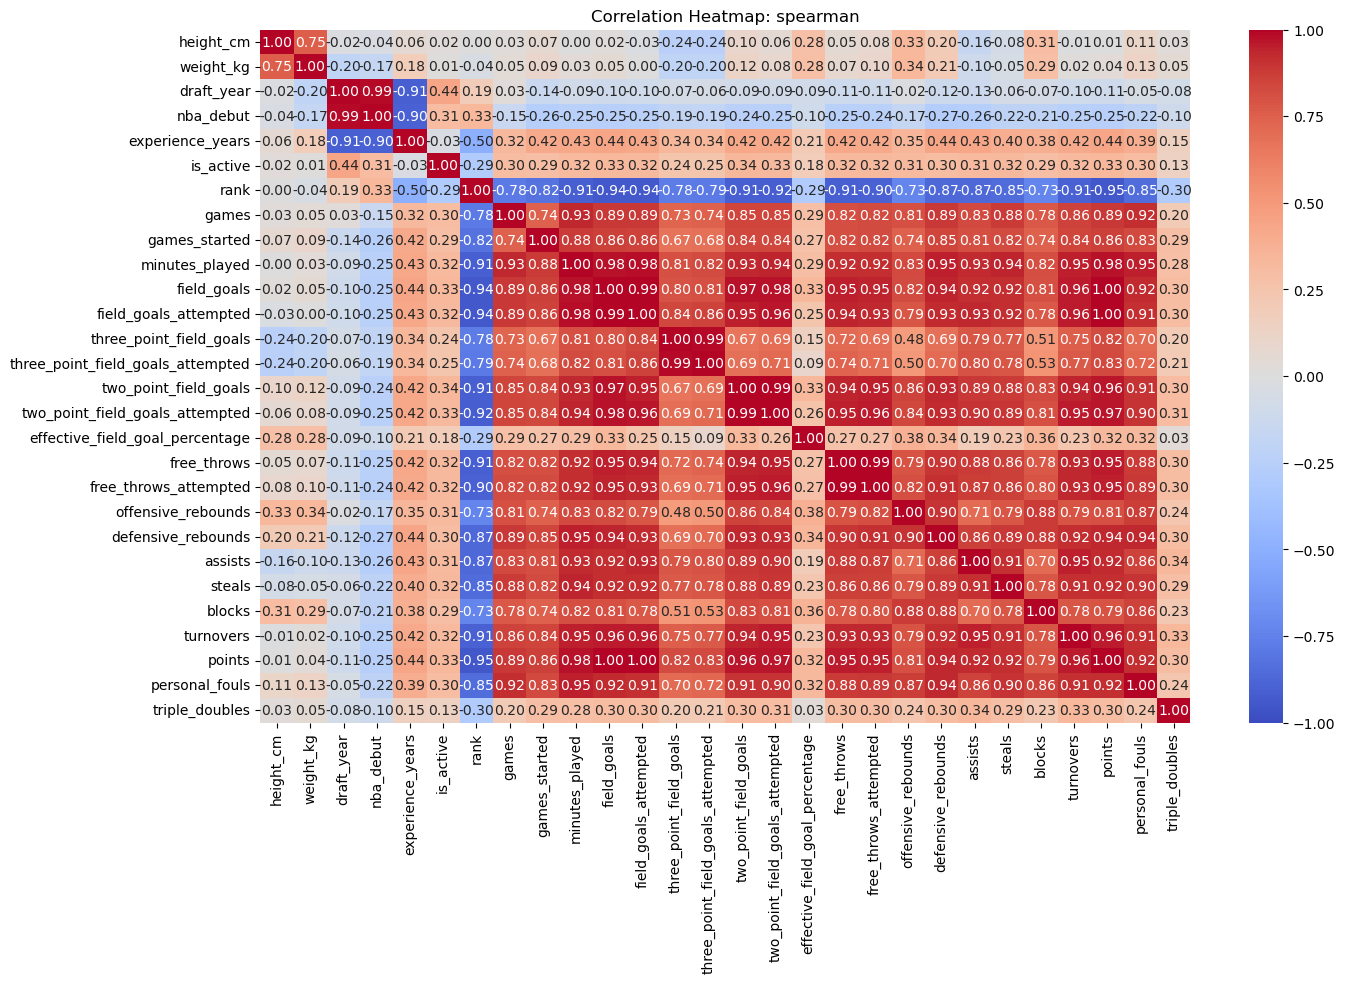

In [45]:
corr_heatmap(df)

### 3) Do experience groups differ in production?
- **Variables:** `experience_years`, `points`, `assists`
- **Test:** One-way ANOVA  
- **Suggested groups:** `0–2 years`, `3–6 years`, `7+ years`
- **Null hypothesis (H0):** The mean stat is equal across experience groups.
- **Alternative hypothesis (H1):** At least one experience group has a different mean.

In [46]:
def binning(data, col, method="custom", bins=5, thresholds=None, labels=None):

    df = data.copy()
    new_col = col + "_bin"

    if method == "equal width":
        df[new_col] = pd.cut(df[col], bins=bins, labels=labels)
    elif method == "quantile":
        df[new_col] = pd.qcut(df[col], q=bins, labels=labels, duplicates="drop")
    elif method == "custom":
        df[new_col] = pd.cut(df[col], bins=thresholds, labels=labels)

    print("column:", new_col)
    print("number of groups:", df[new_col].nunique())

    return df

In [ ]:
# we can change this binning later if necessary

In [53]:
df = binning(df , 'experience_years' , method="custom" , bins=3 , thresholds=[0 , 2 , 8 , np.inf] , 
            labels=["Rookie" , "Established" , "Veteran"])

column: experience_years_bin
number of groups: 3


In [54]:
df['experience_years_bin'].value_counts()

experience_years_bin
Established    2467
Veteran        1429
Rookie          617
Name: count, dtype: int64

In [55]:
anova_test_pro(df , "experience_years_bin" , "points" , equal_var=False)

,multi_category,target,F_stat,P_value,result
0,experience_years_bin,points,420.707716,5.686718e-154,Significant


In [57]:
anova_test_pro(df , "experience_years_bin" , "assists" , equal_var=False)

,multi_category,target,F_stat,P_value,result
0,experience_years_bin,assists,274.115128,9.760306e-106,Significant


In [58]:
anova_test_pro(df , "experience_years_bin" , 'effective_field_goal_percentage' , equal_var=False)

,multi_category,target,F_stat,P_value,result
0,experience_years_bin,effective_field_goal_percentage,63.316037,4.170069e-27,Significant


### 4) Do starters score more than non-starters?
- **Variables:** `games_started`, `points`, `minutes_played`, `assists`
- **Test:** Mann-Whitney U
- **Groups:** starters vs non-starters
- **Null hypothesis (H0):** The mean stat is the same for starters and non-starters.
- **Alternative hypothesis (H1):** The mean stat is different between the two groups.

In [61]:
non_starter = df[df['games_started'] == 0].dropna()
starter = df[df['games_started'] != 0].dropna()

In [65]:
u_stat, p_value = mannwhitneyu(non_starter['points'] , starter['points'] , alternative='two-sided')
p_value

np.float64(6.462098525857283e-250)

In [66]:
u_stat, p_value = mannwhitneyu(non_starter['effective_field_goal_percentage'] , starter['effective_field_goal_percentage'] , alternative='two-sided')
p_value

np.float64(5.6565056809450155e-37)

In [67]:
u_stat, p_value = mannwhitneyu(non_starter['minutes_played'] , starter['minutes_played'] , alternative='two-sided')
p_value

np.float64(1.7479375315668174e-259)

### 5) Do right-handed players score more than the left-handed ones?
- **Variables:** `shoots`, `points`, `minutes_played`, `assists`
- **Test:** Mann-Whitney U
- **Groups:** right vs left
- **Null hypothesis (H0):** There is no significant difference in player performance between right-handed and left-handed shooters.
- **Alternative hypothesis (H1):** There is a significant difference in player performance between right-handed and left-handed shooters.

In [72]:
right = df[df['shoots'] == 'Right'].dropna()
left = df[df['shoots'] == 'Left'].dropna()

In [75]:
u_stat, p_value = mannwhitneyu(right['points'] , left['points'] , alternative='two-sided')
p_value

np.float64(0.07567314043453165)